In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as f

spark = SparkSession \
    .builder \
    .appName("BDLC_Parking_Violations_Analysis") \
    .master("spark://bdlc-012.bdlc.ls.eee.intern:7077") \
    .getOrCreate()

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 01:23:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/05/19 01:23:22 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [3]:
%%time
processed_path = "hdfs:///parking_violations/processed/parking_violations_cleaned"

df = spark.read.parquet(processed_path)
df.cache()
df.count()

26/05/19 01:26:55 WARN CacheManager: Asked to cache already cached data.


CPU times: user 993 μs, sys: 3.6 ms, total: 4.6 ms
Wall time: 578 ms


54220652

In [4]:
df.printSchema()

root
 |-- summons_number: string (nullable = true)
 |-- plate_id: string (nullable = true)
 |-- registration_state: string (nullable = true)
 |-- issue_date: string (nullable = true)
 |-- violation_time: string (nullable = true)
 |-- violation_county: string (nullable = true)
 |-- violation_precinct: string (nullable = true)
 |-- street_name: string (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- vehicle_body_type: string (nullable = true)
 |-- violation_code: string (nullable = true)
 |-- violation_description: string (nullable = true)
 |-- issue_date_parsed: date (nullable = true)
 |-- issue_year: integer (nullable = true)
 |-- issue_month: integer (nullable = true)
 |-- issue_weekday: integer (nullable = true)
 |-- violation_time_clean: string (nullable = true)
 |-- time_hour_raw: integer (nullable = true)
 |-- violation_minute: integer (nullable = true)
 |-- time_ampm: string (nullable = true)
 |-- violation_hour: integer (nullable = true)
 |-- fiscal_year: integ

## Analyse 1: Häufigste Parking Violation Typen FY2023–FY2025
Welche Violation-Typen kommen am häufigsten vor und wie verändern sie sich über die Jahre?

In [6]:
%%time
violation_by_year = df.groupBy("fiscal_year", "violation_code", "violation_description") \
    .count() \
    .orderBy("fiscal_year", f.desc("count"))

violation_by_year.show(20, truncate=False)

+-----------+--------------+------------------------------+-------+
|fiscal_year|violation_code|violation_description         |count  |
+-----------+--------------+------------------------------+-------+
|2023       |36            |PHTO SCHOOL ZN SPEED VIOLATION|8042072|
|2023       |21            |21-No Parking (street clean)  |1930233|
|2023       |38            |38-Failure to Dsplay Meter Rec|1403498|
|2023       |14            |14-No Standing                |1004175|
|2023       |7             |FAILURE TO STOP AT RED LIGHT  |889775 |
|2023       |5             |BUS LANE VIOLATION            |747733 |
|2023       |40            |40-Fire Hydrant               |746171 |
|2023       |71            |71A-Insp Sticker Expired (NYS)|674969 |
|2023       |21            |No Parking Street Cleaning    |652119 |
|2023       |20            |20A-No Parking (Non-COM)      |591174 |
|2023       |70            |70A-Reg. Sticker Expired (NYS)|443586 |
|2023       |37            |37-Expired Parking M

### Resultate
Violation Code 36 (Schulzone Tempolimit) dominiert mit über 8 Mio. Verstössen in FY2023 
deutlich. Code 21 (Parkverbot Strassenreinigung) und Code 38 (Parkuhr) folgen auf 
Platz 2 und 3.

### Visualisierung Top 10
Die häufigsten Violation-Typen über alle drei Fiskaljahre (2023–2025) zusammengefasst.

<Axes: title={'center': 'Top 10 Parking Violations FY2023–FY2025'}, xlabel='Anzahl Violations', ylabel='violation_description'>

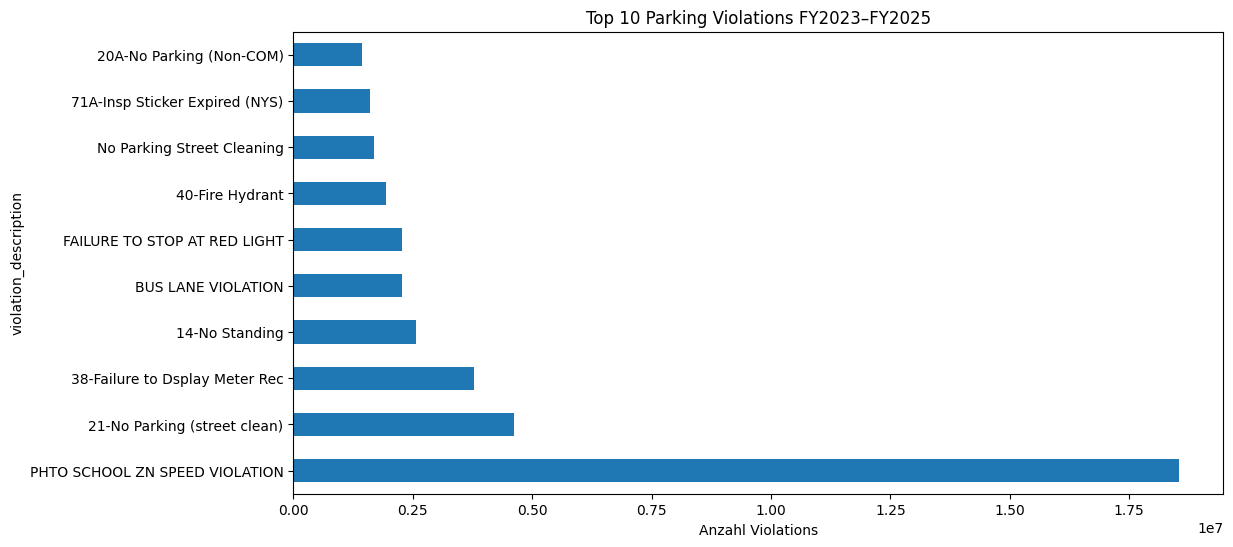

In [9]:
# Top 10 Violation Codes gesamt
top10 = df.groupBy("violation_code", "violation_description") \
    .count() \
    .orderBy(f.desc("count")) \
    .limit(10) \
    .toPandas()

top10.plot(
    x="violation_description",
    y="count",
    kind="barh",
    figsize=(12, 6),
    title="Top 10 Parking Violations FY2023–FY2025",
    xlabel="Anzahl Violations",
    legend=False
)

### Trend über die Jahre
Verändern sich die häufigsten Violations über FY2023, FY2024 und FY2025?

<Axes: title={'center': 'Top 5 Violation Codes pro Jahr'}, xlabel='fiscal_year'>

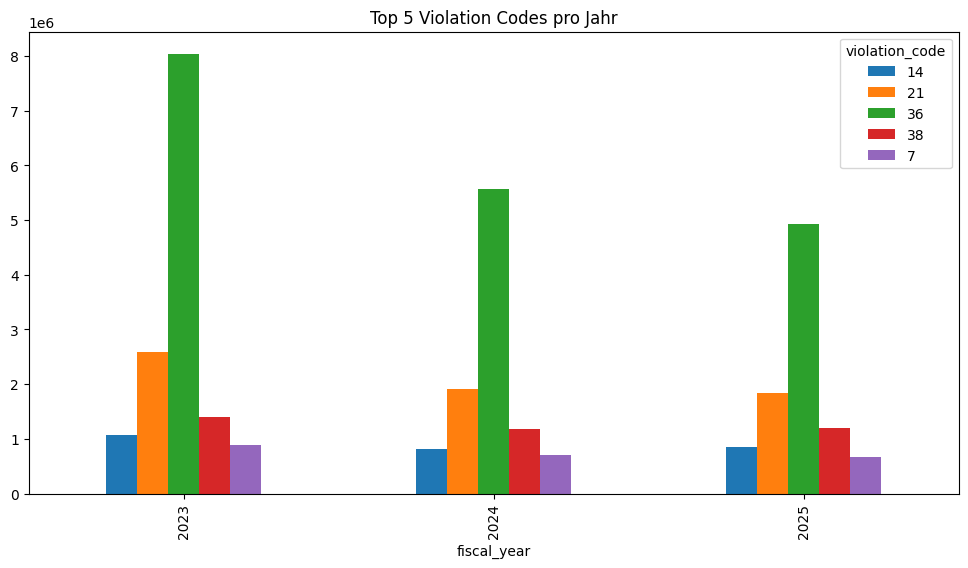

In [10]:
# Top 5 Codes pro Jahr
top5_codes = ["36", "21", "38", "14", "7"]

yearly_trend = df.filter(f.col("violation_code").isin(top5_codes)) \
    .groupBy("fiscal_year", "violation_code") \
    .count() \
    .orderBy("violation_code", "fiscal_year") \
    .toPandas()

yearly_trend.pivot(index="fiscal_year", columns="violation_code", values="count") \
    .plot(kind="bar", figsize=(12, 6), title="Top 5 Violation Codes pro Jahr")

### Detailzahlen Code 36
Um die Veränderung über die Jahre genau zu beziffern, schauen wir uns 
die absoluten Zahlen für den häufigsten Verstoss an.

In [11]:
%%time
yearly_counts = df.filter(f.col("violation_code") == "36") \
    .groupBy("fiscal_year") \
    .count() \
    .orderBy("fiscal_year") \
    .toPandas()

print("Code 36 - PHTO SCHOOL ZN SPEED VIOLATION:")
print(yearly_counts.to_string(index=False))

[Stage 23:====================================================>   (13 + 1) / 14]

Code 36 - PHTO SCHOOL ZN SPEED VIOLATION:
 fiscal_year   count
        2023 8042072
        2024 5573363
        2025 4926435
CPU times: user 11.5 ms, sys: 3.66 ms, total: 15.2 ms
Wall time: 1.16 s


### Detailzahlen Top 5 Codes
Übersicht aller Top-5 Violation Codes mit exakten Zahlen pro Fiskaljahr.

In [12]:
summary = df.filter(f.col("violation_code").isin(["36", "21", "38", "14", "7"])) \
    .groupBy("fiscal_year", "violation_code", "violation_description") \
    .count() \
    .orderBy("violation_code", "fiscal_year") \
    .toPandas()

print(summary.to_string(index=False))

 fiscal_year violation_code          violation_description   count
        2023             14                        Unknown   44690
        2023             14                 14-No Standing 1004175
        2023             14                    No Standing   13486
        2024             14                 14-No Standing  760997
        2024             14                        Unknown   35192
        2024             14                    No Standing   10221
        2025             14                        Unknown   34948
        2025             14                 14-No Standing  802455
        2025             14                    No Standing    7680
        2023             21     No Parking Street Cleaning  652119
        2023             21   21-No Parking (street clean) 1930233
        2023             21                             ;$       1
        2023             21                        Unknown    9208
        2024             21     No Parking Street Cleaning  51

### Anmerkung zu "Unknown"
Einige Einträge zeigen `Unknown` als `violation_description`. Diese stammen aus 
dem Pre-Processing, wo fehlende Beschreibungsfelder mit `Unknown` ersetzt wurden. 
Die Anzahl ist vernachlässigbar klein (< 0.5% pro Code) und beeinflusst die 
Analyse nicht. Für die weitere Auswertung werden diese Einträge gefiltert.

In [13]:
%%time
summary_clean = df.filter(f.col("violation_code").isin(["36", "21", "38", "14", "7"])) \
    .filter(f.col("violation_description") != "Unknown") \
    .groupBy("fiscal_year", "violation_code") \
    .count() \
    .orderBy("violation_code", "fiscal_year") \
    .toPandas()

print(summary_clean.to_string(index=False))

[Stage 39:============================================>           (11 + 3) / 14]

 fiscal_year violation_code   count
        2023             14 1017661
        2024             14  771218
        2025             14  810135
        2023             21 2582353
        2024             21 1904615
        2025             21 1830216
        2023             36 8042072
        2024             36 5573361
        2025             36 4926435
        2023             38 1403498
        2024             38 1182440
        2025             38 1196732
        2023              7  889775
        2024              7  712368
        2025              7  664341
CPU times: user 10.5 ms, sys: 9.62 ms, total: 20.1 ms
Wall time: 2.06 s


### Interpretation
- Code 36 (Schulzone Tempolimit) ist mit Abstand der häufigste Verstoss, 
  sinkt aber von 8 Mio. (FY2023) auf 4.9 Mio. (FY2025) — ein Rückgang von ~39%.
- Code 21 (Parkverbot Strassenreinigung) bleibt stabil auf Platz 2.
- Alle Top-5 Codes zeigen einen leichten Rückgang über die drei Jahre.
- Die Reihenfolge der häufigsten Violations bleibt über alle Jahre konstant.

### Fazit Analyse 1
Die Frage "Welche Violation-Typen kommen am häufigsten vor?" kann klar beantwortet werden:

Code 36 (Schulzone Tempolimit) dominiert mit grossem Abstand — dies ist womöglich auf
automatische Fotoblitzer in Schulzonen zurückzuführen. Bemerkenswert ist der 
kontinuierliche Rückgang über alle Top-Codes von FY2023 auf FY2025, was auf 
weniger Verstösse oder veränderte Enforcement-Strategien hindeuten könnte.